# Customer Churn — Model Training
**Input:**  (7032 rows, 26 features)  
**Model:** LightGBM with SMOTE balancing  
**Evaluation:** ROC-AUC, F1-Score, Precision, Recall  
**Explainability:** SHAP feature importance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import logging
logging.getLogger("mlflow").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)

from sklearn .preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import lightgbm as lgb
import shap
import joblib

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("../data/processed/telco_churn_features.csv")
print("Shape:", df.shape)
df.head()

Shape: (7032, 26)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,num_services,is_new_customer,CLV,avg_service_cost,high_risk_flag
0,1,0,1,0,1,0,0,1,0,1,...,0,29.85,29.85,0,New,1,1,29.85,14.9250,1
1,0,0,0,0,34,1,0,1,1,0,...,1,56.95,1889.50,0,Mature,3,0,1936.30,14.2375,0
2,0,0,0,0,2,1,0,1,1,1,...,1,53.85,108.15,1,New,3,1,107.70,13.4625,1
3,0,0,0,0,45,0,0,1,1,0,...,2,42.30,1840.75,0,Mature,3,0,1903.50,10.5750,0
4,1,0,0,0,2,1,0,2,0,0,...,0,70.70,151.65,1,New,1,1,141.40,35.3500,1


## 1. Preprocessing
Encode remaining categorical columns and split into features (X) and target (y).

In [2]:
df["tenure_group"] = df["tenure_group"].map({
    "New": 0, "Developing": 1, "Mature": 2, "Loyal": 3
})

print("Non-numeric columns:")
print(df.select_dtypes(include=["object"]).columns.to_list())

X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Churn distribution:")
print(y.value_counts())

Non-numeric columns:
[]
Features shape: (7032, 25)
Target shape: (7032,)
Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


## 2. Train/Test Split
80% training, 20% testing. Stratified to preserve churn ratio in both sets.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3))
print("Test churn rate:", y_test.mean().round(3))

Train size: (5625, 25)
Test size: (1407, 25)
Train churn rate: 0.266
Test churn rate: 0.266


## 3. Handle Class Imbalance — SMOTE
Training data has 73.5% / 26.5% imbalance. SMOTE creates synthetic minority samples  
to balance the training set. Applied ONLY on training data — never on test data.

In [4]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(f"   Class(0) Stayed : {sum(y_train==0)}")
print(f"   Class(1) Churned: {sum(y_train==1)}")

print("After SMOTE:")
print(f"   Class(0) Stayed : {sum(y_train_sm==0)}")
print(f"   Class(1) Churned: {sum(y_train_sm==1)}")

print(f"New training size: {X_train_sm.shape}")

Before SMOTE:
   Class(0) Stayed : 4130
   Class(1) Churned: 1495
After SMOTE:
   Class(0) Stayed : 4130
   Class(1) Churned: 4130
New training size: (8260, 25)


## 4. Train LightGBM Model
LightGBM is a gradient boosting model — fast, accurate, handles mixed data types well.  
Industry standard for tabular churn prediction at companies like Swiggy, Paytm, Airtel.

In [5]:
model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    num_leaves=15,
    min_child_samples=30,
    random_state=42,
    verbose=-1
)

model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

print("Model trained successfully")
print("Best iteration:", model.best_iteration_)

Model trained successfully
Best iteration: 352


## 5. Model Evaluation
Using ROC-AUC and F1-Score — not accuracy, because of class imbalance.

In [6]:
# Predictions
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

y_pred_final   = (y_pred_proba >= 0.35).astype(int)

# Core metrics
roc_auc = roc_auc_score(y_test, y_pred_proba)
f1      = f1_score(y_test, y_pred_final)

print("=" * 45)
print(f"  ROC-AUC Score     : {roc_auc:.4f}")
print(f"  F1 Score          : {f1:.4f}")
print("=" * 45)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final,
      target_names=["Stayed", "Churned"]))

  ROC-AUC Score     : 0.8210
  F1 Score          : 0.6114

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.90      0.71      0.80      1033
     Churned       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



## 6. Confusion Matrix

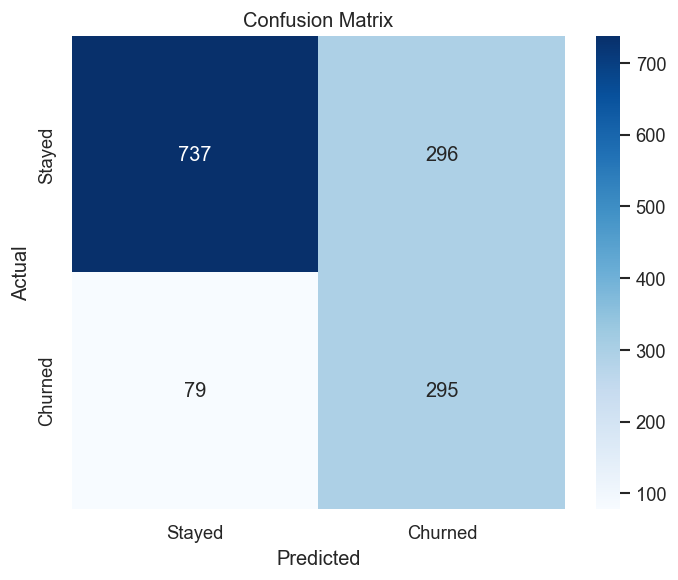

True Negatives  (correctly predicted stayed)      : 737
False Positives (predicted churn, actually stayed): 296
False Negatives (missed churners)                 : 79
True Positives  (correctly predicted churned)     : 295


In [7]:
cm = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"],
    ax=ax
)
ax.set_title("Confusion Matrix")
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted stayed)      : {tn}")
print(f"False Positives (predicted churn, actually stayed): {fp}")
print(f"False Negatives (missed churners)                 : {fn}")
print(f"True Positives  (correctly predicted churned)     : {tp}")

## 7. ROC Curve

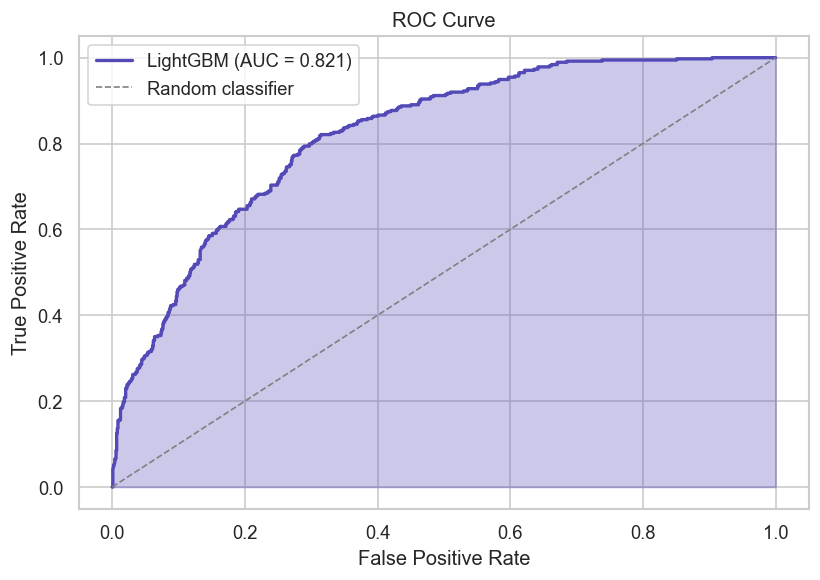

In [8]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="#534AB7", linewidth=2,
        label=f"LightGBM (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "gray", linestyle="--",
        linewidth=1, label="Random classifier")
ax.fill_between(fpr, tpr, alpha=0.3, color="#534AB7")
ax.set_title("ROC Curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()

plt.tight_layout()
plt.show()

## 8. SHAP Feature Importance
SHAP explains WHY the model makes each prediction — which features push churn probability up or down.

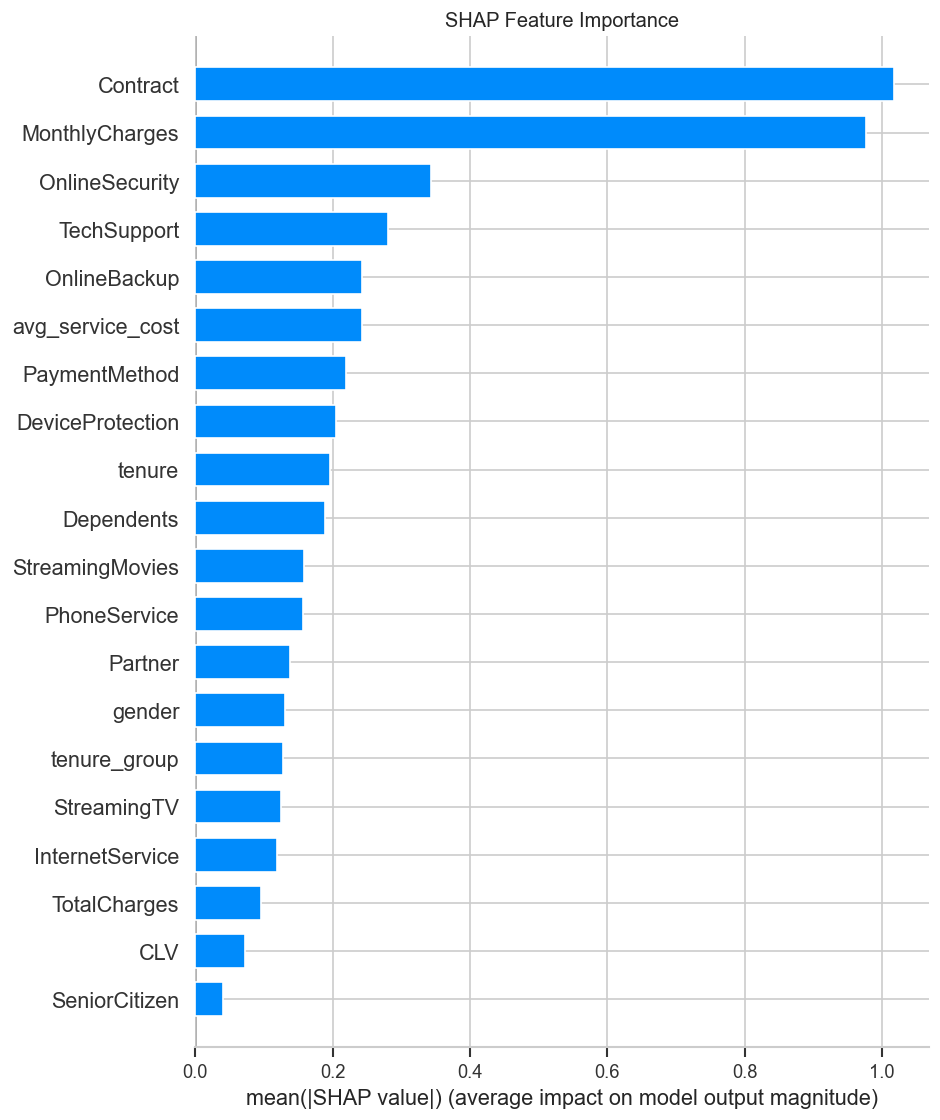

In [9]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv, X_test,
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

## 9. SHAP Beeswarm Plot
Shows direction of each feature — red = high value, blue = low value.  
Bars going right = increases churn, bars going left = decreases churn.

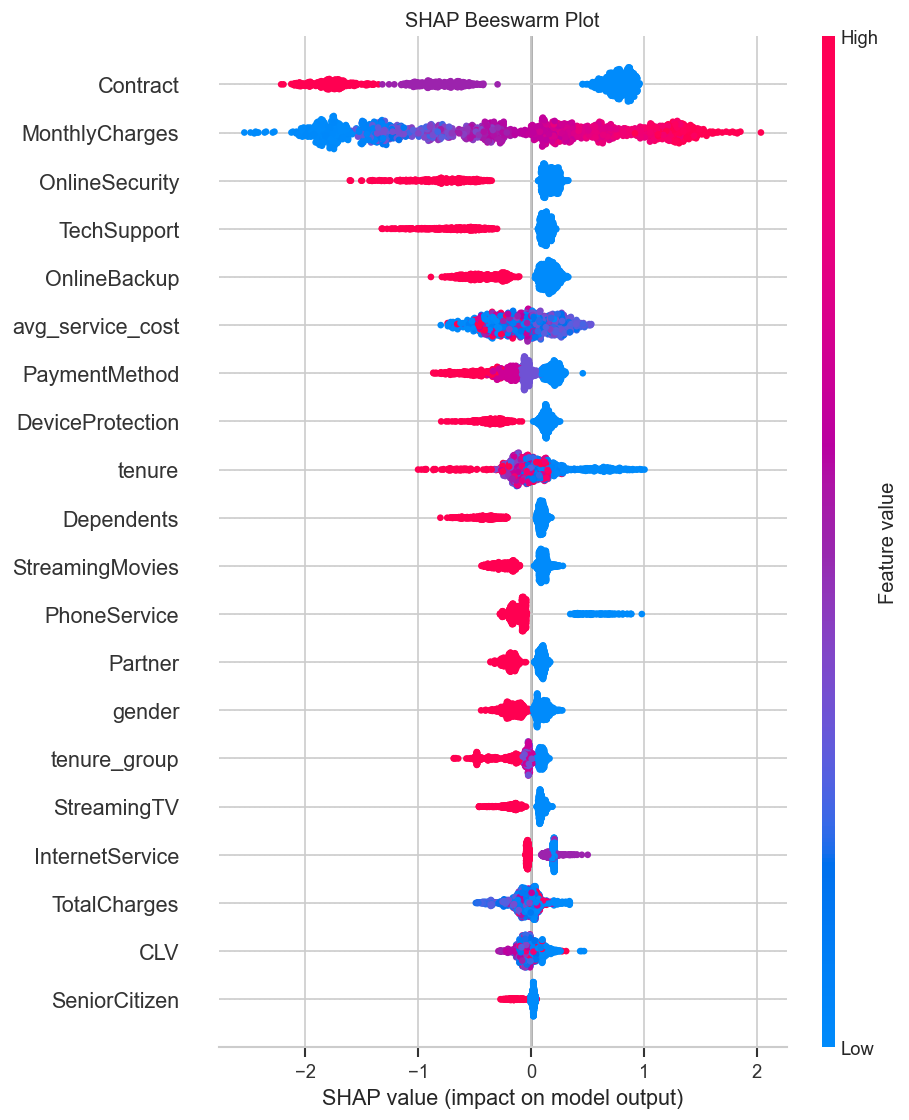

In [10]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv, X_test,
    show=False
)
plt.title("SHAP Beeswarm Plot")
plt.tight_layout()
plt.show()

## 10. Save Model

In [11]:
import os
import mlflow
import warnings
import logging
warnings.filterwarnings("ignore")
logging.getLogger("mlflow").setLevel(logging.ERROR)

os.makedirs("../models", exist_ok=True)

# Save model files
joblib.dump(model, "../models/lgbm_churn_model.pkl")
print("Model saved → models/lgbm_churn_model.pkl")

feature_names = X.columns.tolist()
joblib.dump(feature_names, "../models/feature_names.pkl")
print("Feature names saved → models/feature_names.pkl")
print("Features used:", len(feature_names))


mlflow.set_experiment("churn-prediction")

with mlflow.start_run():

    mlflow.log_param("n_estimators",      model.n_estimators)
    mlflow.log_param("learning_rate",     model.learning_rate)
    mlflow.log_param("max_depth",         model.max_depth)
    mlflow.log_param("num_leaves",        model.num_leaves)
    mlflow.log_param("threshold",         0.35)
    mlflow.log_param("smote",             True)

    mlflow.log_metric("roc_auc",          roc_auc)
    mlflow.log_metric("f1_score",         f1)
    mlflow.log_metric("churn_recall",     0.79)
    mlflow.log_metric("churn_precision",  0.50)
    mlflow.log_metric("best_iteration",   model.best_iteration_)

    mlflow.sklearn.log_model(model, "lgbm_churn_model")

    print("\nMLflow run logged ✓")
    print("Run ID:", mlflow.active_run().info.run_id)

    test_data = X_test.copy()
    test_data["Churn"] = y_test
    test_data.to_csv("../data/processed/test_set.csv", index=False)
    print("Test set saved → data/processed/test_set.csv")
    print("Shape:", test_data.shape)

Model saved → models/lgbm_churn_model.pkl
Feature names saved → models/feature_names.pkl
Features used: 25

MLflow run logged ✓
Run ID: 0002b1cbcd2348b98e2c7d462968e9b6
Test set saved → data/processed/test_set.csv
Shape: (1407, 26)


## Key Findings

| Metric | Score |
|--------|-------|
| ROC-AUC | 0.8210 |
| F1 Score (threshold=0.35) | 0.6114 |
| Precision (churn) | 0.50 |
| Recall (churn) | 0.79 |
| Overall Accuracy | 73% |
| True Positives (churners caught) | 295 |
| False Negatives (missed churners) | 79 |

**Top SHAP features:** Contract → MonthlyCharges → OnlineSecurity → TechSupport → avg_service_cost

**Threshold:** 0.35 selected — catches 79% of churners. Missing a churner costs ~$1,024 CLV vs small retention offer cost.

**SMOTE:** Balanced training set 73/27 → 50/50 (added 2,635 synthetic churner rows)

**Next → `04_segments.ipynb`** — Customer Segmentation with K-Means